# Does Malaysia Actually Have a Graduate Unemployment Crisis?

## The Question

Malaysian media and social commentary regularly describe a "graduate unemployment crisis", the idea that a degree no longer reliably leads to a job. Does that framing hold up against DOSM's own headline numbers, before we even look at age, geography, or job quality?

## The Answer

Not at the headline level. In both 2023 and 2024, Malaysia's graduate unemployment rate was **identical** to the national unemployment rate; 3.4% in 2023, 3.2% in 2024. A graduate in Malaysia is not, on this measure, meaningfully more likely to be unemployed than anyone else in the labour force. If a "crisis" exists, the headline rate is the wrong place to find it, which is exactly why this case study keeps digging in Notebooks 02–06 instead of stopping here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
national = pd.read_csv('../data/processed/national_unemployment_1982_2023.csv')
grad = pd.read_csv('../data/processed/graduate_vs_national_unemployment.csv')
grad

,year,graduate_unemployment_rate_pct,national_unemployment_rate_pct,total_graduates_million,unemployed_graduates_thousand,glfpr_pct
0,2023,3.4,3.4,NaN,167.3,NaN
1,2024,3.2,3.2,5.98,165.9,86.0


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Graduate vs. national unemployment rate, side by side

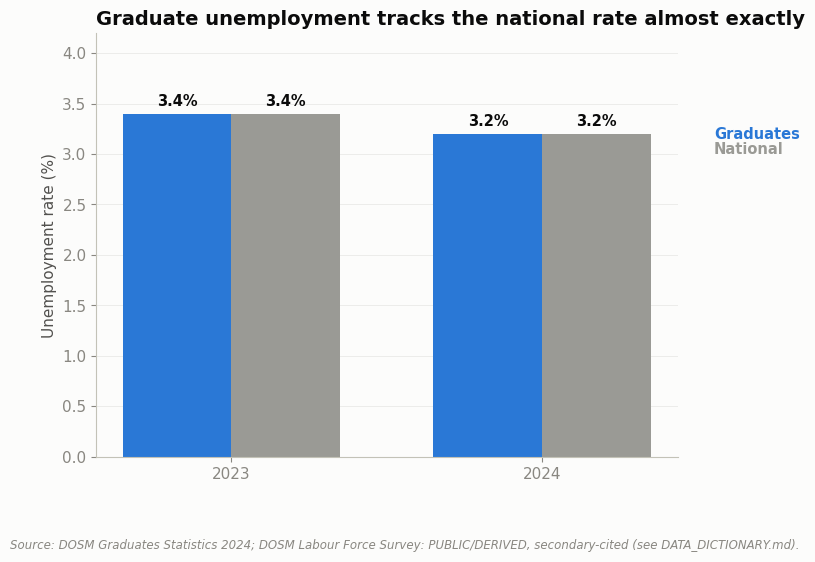

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
years = grad['year'].astype(str)
x = range(len(years))
w = 0.35
bars_g = ax.bar([i - w/2 for i in x], grad['graduate_unemployment_rate_pct'], width=w, color=ACCENT_1, label='Graduates')
bars_n = ax.bar([i + w/2 for i in x], grad['national_unemployment_rate_pct'], width=w, color=GRAY, label='National (everyone)')
for bars in (bars_g, bars_n):
    for b in bars:
        ax.annotate(f'{b.get_height():.1f}%', xy=(b.get_x()+b.get_width()/2, b.get_height()),
                    xytext=(0, 6), textcoords='offset points', ha='center', fontsize=10.5, fontweight='semibold')
ax.set_xticks(list(x)); ax.set_xticklabels(years)
ax.set_ylim(0, 4.2)
ax.set_title('Graduate unemployment tracks the national rate almost exactly', loc='left')
ax.set_ylabel('Unemployment rate (%)')
end_label(ax, 1.15, grad['graduate_unemployment_rate_pct'].iloc[-1], 'Graduates', ACCENT_1, offset=90)
end_label(ax, 1.15, grad['national_unemployment_rate_pct'].iloc[-1]-0.15, 'National', GRAY, offset=90)
add_source(ax.figure, 'Source: DOSM Graduates Statistics 2024; DOSM Labour Force Survey: PUBLIC/DERIVED, secondary-cited (see DATA_DICTIONARY.md).')
plt.show()

## The long-run context: national unemployment since 1982

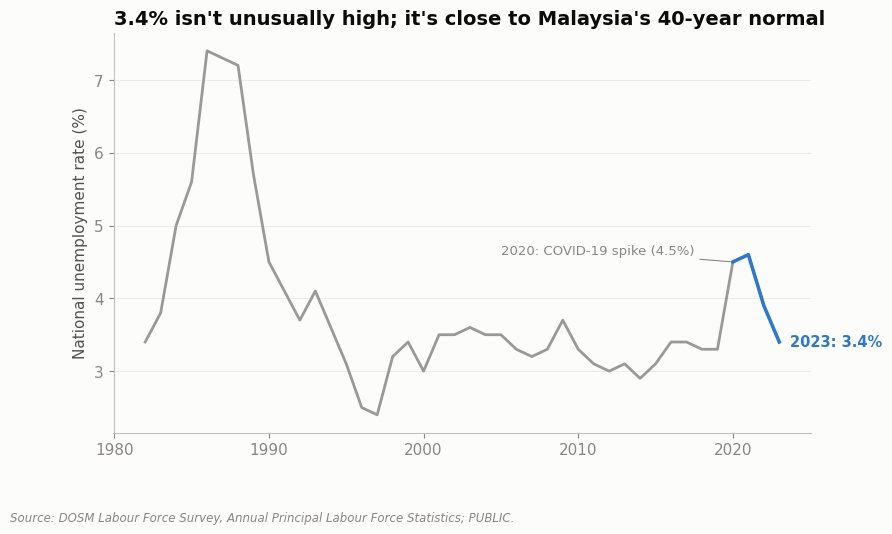

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(national['year'], national['unemployment_rate_pct'], color=GRAY, linewidth=2)
recent = national[national['year'] >= 2020]
ax.plot(recent['year'], recent['unemployment_rate_pct'], color=ACCENT_1, linewidth=2.5)
end_label(ax, national['year'].iloc[-1], national['unemployment_rate_pct'].iloc[-1], '2023: 3.4%', ACCENT_1)
ax.annotate('2020: COVID-19 spike (4.5%)', xy=(2020, 4.5), xytext=(2005, 4.6),
            fontsize=9.5, color=INK_MUTED, arrowprops=dict(arrowstyle='-', color=INK_MUTED, lw=0.8))
ax.set_title("3.4% isn't unusually high; it's close to Malaysia's 40-year normal", loc='left')
ax.set_ylabel('National unemployment rate (%)')
add_source(ax.figure, 'Source: DOSM Labour Force Survey, Annual Principal Labour Force Statistics; PUBLIC.')
plt.show()

## Strategic Recommendation

- **Stop citing the headline unemployment rate as evidence of a graduate-specific crisis; it isn't one.** Graduates and the general labour force have posted essentially the same unemployment rate in both years DOSM has published a direct comparison. Any business or policy argument built on "graduates can't find jobs" needs a different, more specific metric to stand on.
- **The real question isn't *whether* graduates are unemployed; it's *which* graduates, and in what kind of job.** Notebooks 02 and 03 test the two most likely candidates: age (are fresh graduates specifically worse off?) and job quality (are employed graduates in the right kind of job?).

## Confidence & Caveats

- **The graduate-specific comparison only has two data points (2023, 2024).** DOSM's Graduates Statistics report is annual and this session could not machine-read the primary PDF (binary/compressed format); the exact figures used here are DERIVED from a secondary-cited summary of that report, not independently verified against the primary document page-by-page. See `DATA_DICTIONARY.md`.
- **A flat headline rate does not mean nothing is wrong**; it means whatever is wrong isn't visible at this level of aggregation. That is the explicit premise the rest of this case study tests.